# Week 13 Lab — Transformer Model for Spam Email Detection
**BFOR 516 | Advanced Data Analytics for Cyber**

Dataset: SpamAssassin (`label`: 0 = ham, 1 = spam)

## 1. Load Libraries

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


## 2. Load and Prepare Data

In [19]:
df = pd.read_csv('SpamAssasin.csv', encoding='utf-8', on_bad_lines='skip')

# Inspect the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nLabel distribution (0=ham, 1=spam):")
print(df['label'].value_counts())
print(f"\nLabel percentages:")
print(df['label'].value_counts(normalize=True).round(3))

Dataset shape: (5809, 7)

Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

First few rows:
                                      sender  \
0             Robert Elz <kre@munnari.OZ.AU>   
1  Steve Burt <Steve_Burt@cursor-system.com>   
2              "Tim Chapman" <timc@2ubh.com>   
3           Monty Solomon <monty@roscom.com>   
4  Stewart Smith <Stewart.Smith@ee.ed.ac.uk>   

                                            receiver  \
0  Chris Garrigues <cwg-dated-1030377287.06fa6d@D...   
1  "'zzzzteana@yahoogroups.com'" <zzzzteana@yahoo...   
2              zzzzteana <zzzzteana@yahoogroups.com>   
3                           undisclosed-recipient: ;   
4                          zzzzteana@yahoogroups.com   

                              date  \
0  Thu, 22 Aug 2002 18:26:25 +0700   
1  Thu, 22 Aug 2002 12:46:18 +0100   
2  Thu, 22 Aug 2002 13:52:38 +0100   
3  Thu, 22 Aug 2002 09:15:25 -0400   
4  Thu, 22 Aug 2002 14:38:22 +0100   

                          

In [20]:
# Combine subject and body for richer context
df['email_text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')

def clean_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text)                        # collapse whitespace
    text = re.sub(r'\S+@\S+', '[EMAIL]', text)              # mask email addresses
    text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text) # mask URLs
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)             # strip non-ASCII
    return text.strip()

df['email_text'] = df['email_text'].apply(clean_text)

# Drop rows with missing labels or empty text
df = df.dropna(subset=['label'])
df = df[df['email_text'].str.strip() != '']
df['label'] = df['label'].astype(int)

print(f"Final dataset shape after cleaning: {df.shape}")
print(f"\nSample cleaned email (first 300 chars):")
print(df['email_text'].iloc[0][:300])

Final dataset shape after cleaning: (5809, 8)

Sample cleaned email (first 300 chars):
Re: New Sequences Window Date: Wed, 21 Aug 2002 10:54:46 -0500 From: Chris Garrigues Message-ID: [EMAIL] | I can't reproduce this error. For me it is very repeatable... (like every time, without fail). This is the debug log of the pick happening ... 18:19:03 Pick_It {exec pick +inbox -list -lbrace -


## 3. Model Parameters

Tuned for CPU training — balanced between capacity and speed.

In [21]:
# --- Vocabulary & Sequence ---
MAX_VOCAB       = 8000   # top 8k words covers the spam/ham vocabulary well
MAX_SEQUENCE_LEN = 200   # 200 tokens captures most email signal without blowing memory

# --- Transformer Architecture ---
EMBED_DIM              = 64   # embedding dimension per token
NUM_HEADS              = 4    # attention heads; key_dim = 64 // 4 = 16
FF_DIM                 = 128  # feed-forward hidden layer size
NUM_TRANSFORMER_BLOCKS = 2    # stacked encoder blocks
DROPOUT_RATE           = 0.3  # regularization

# --- Training ---
BATCH_SIZE = 32
EPOCHS     = 15

print("Model parameters:")
params = {
    'MAX_VOCAB': MAX_VOCAB, 'MAX_SEQUENCE_LEN': MAX_SEQUENCE_LEN,
    'EMBED_DIM': EMBED_DIM, 'NUM_HEADS': NUM_HEADS, 'FF_DIM': FF_DIM,
    'NUM_TRANSFORMER_BLOCKS': NUM_TRANSFORMER_BLOCKS,
    'DROPOUT_RATE': DROPOUT_RATE, 'BATCH_SIZE': BATCH_SIZE, 'EPOCHS': EPOCHS
}
for k, v in params.items():
    print(f"  {k:26s} = {v}")

Model parameters:
  MAX_VOCAB                  = 8000
  MAX_SEQUENCE_LEN           = 200
  EMBED_DIM                  = 64
  NUM_HEADS                  = 4
  FF_DIM                     = 128
  NUM_TRANSFORMER_BLOCKS     = 2
  DROPOUT_RATE               = 0.3
  BATCH_SIZE                 = 32
  EPOCHS                     = 15


## 4. Text Vectorization

In [22]:
# Build vocabulary from training corpus
text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_VOCAB,
    output_sequence_length=MAX_SEQUENCE_LEN,
    standardize='lower_and_strip_punctuation'
)
text_vectorizer.adapt(df['email_text'].values)

print(f"Vocabulary size: {len(text_vectorizer.get_vocabulary())}")
print(f"Sample vocabulary (first 20 tokens): {text_vectorizer.get_vocabulary()[:20]}")

# Vectorize all emails
X = text_vectorizer(df['email_text'].values).numpy()
y = df['label'].values.astype(np.float32)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}, dtype: {y.dtype}")

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Train class distribution (ham/spam): {np.bincount(y_train.astype(int))}")
print(f"Test class distribution  (ham/spam): {np.bincount(y_test.astype(int))}")

Vocabulary size: 8000
Sample vocabulary (first 20 tokens): ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('and'), np.str_('of'), np.str_('a'), np.str_('url'), np.str_('in'), np.str_('you'), np.str_('is'), np.str_('for'), np.str_('that'), np.str_('i'), np.str_('this'), np.str_('it'), np.str_('on'), np.str_('email'), np.str_('your'), np.str_('with')]

X shape: (5809, 200)
y shape: (5809,), dtype: float32

Training samples : 4647
Testing samples  : 1162
Train class distribution (ham/spam): [3273 1374]
Test class distribution  (ham/spam): [818 344]


## 5. Handle Class Imbalance

Ham  count  : 3273  | weight: 0.7099
Spam count  : 1374  | weight: 1.6910


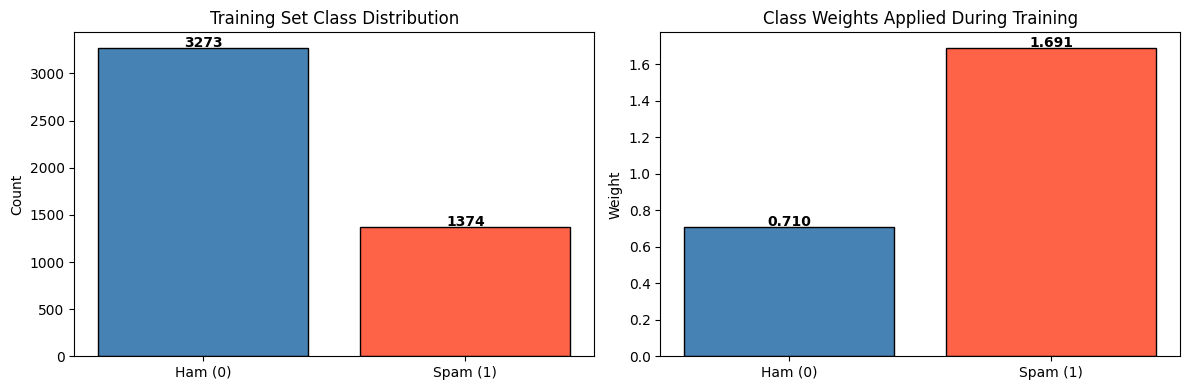

In [23]:
# Class weights penalize the model more for misclassifying the minority class
counts = np.bincount(y_train.astype(int))
class_weight = {
    0: len(y_train) / (2 * counts[0]),  # ham weight
    1: len(y_train) / (2 * counts[1]),  # spam weight
}

print(f"Ham  count  : {counts[0]}  | weight: {class_weight[0]:.4f}")
print(f"Spam count  : {counts[1]}  | weight: {class_weight[1]:.4f}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Ham (0)', 'Spam (1)'], counts, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].bar(['Ham (0)', 'Spam (1)'],
            [class_weight[0], class_weight[1]],
            color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Class Weights Applied During Training')
axes[1].set_ylabel('Weight')
for i, v in enumerate([class_weight[0], class_weight[1]]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Build the Transformer Model

Architecture:
- **PositionalEmbedding**: token embedding + learned positional embedding  
- **TransformerBlock × 2**: Multi-Head Self-Attention → LayerNorm → FFN → LayerNorm  
- **GlobalAveragePooling1D** → Dense(32) → sigmoid output

In [24]:
class PositionalEmbedding(layers.Layer):
    """Token embedding + learned positional embedding, with masking."""

    def __init__(self, seq_len, vocab_size, embed_dim, **kw):
        super().__init__(**kw)
        self.tok = layers.Embedding(vocab_size, embed_dim, mask_zero=True)
        self.pos = layers.Embedding(seq_len, embed_dim)

    def call(self, x):
        positions = tf.range(tf.shape(x)[-1])
        return self.tok(x) + self.pos(positions)


def transformer_block(x, embed_dim, num_heads, ff_dim, dropout):
    """One encoder block: self-attention + FFN, each with residual + LayerNorm."""

    # --- Multi-Head Self-Attention ---
    a = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,  # dimension per head
        dropout=dropout,
    )(x, x)                             # query=key=value (self-attention)
    a = layers.Dropout(dropout)(a)
    x = layers.LayerNormalization(epsilon=1e-6)(x + a)   # residual + norm

    # --- Position-wise Feed-Forward Network ---
    f = layers.Dense(ff_dim, activation='relu')(x)       # expand to ff_dim
    f = layers.Dense(embed_dim)(f)                       # project back to embed_dim
    f = layers.Dropout(dropout)(f)
    return layers.LayerNormalization(epsilon=1e-6)(x + f) # residual + norm


def build_model():
    inp = layers.Input(shape=(MAX_SEQUENCE_LEN,), name='token_ids')

    # Embed tokens with positional information
    x = PositionalEmbedding(
        MAX_SEQUENCE_LEN, MAX_VOCAB, EMBED_DIM, name='pos_embedding'
    )(inp)

    # Stack transformer encoder blocks
    for block_idx in range(NUM_TRANSFORMER_BLOCKS):
        x = transformer_block(x, EMBED_DIM, NUM_HEADS, FF_DIM, DROPOUT_RATE)

    # Aggregate sequence → fixed-size vector
    x = layers.GlobalAveragePooling1D(name='avg_pool')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Classification head
    x = layers.Dense(32, activation='relu', name='classifier_dense')(x)
    out = layers.Dense(1, activation='sigmoid', name='spam_prob')(x)

    return Model(inp, out, name='SpamTransformer')


model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ],
)
model.summary()

Model: "SpamTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_embedding       │ (None, 200, 64)   │    524,800 │ token_ids[0][0]   │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 64)   │     16,640 │ pos_embedding[0]… │
│ (MultiHeadAttentio… │                   │            │ pos_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 200, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 200, 64)   │          0 │ pos_embedding[0]… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 200, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 200, 64)   │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 200, 64)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 200, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 200, 64)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 200, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 64)   │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 200, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 200, 64)   │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 200, 64)   │          0 │ dense_7[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 200, 64)   │          0 │ layer_normalizat

 Total params: 593,857 (2.27 MB)

 Trainable params: 593,857 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

In [8]:
cbs = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=cbs,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.8684 - auc: 0.9455 - loss: 0.2963 - precision: 0.7427 - recall: 0.8418 - val_accuracy: 0.9753 - val_auc: 0.9983 - val_loss: 0.0745 - val_precision: 0.9371 - val_recall: 0.9861 - learning_rate: 0.0010
Epoch 2/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9892 - auc: 0.9986 - loss: 0.0333 - precision: 0.9712 - recall: 0.9926 - val_accuracy: 0.9817 - val_auc: 0.9935 - val_loss: 0.0932 - val_precision: 0.9500 - val_recall: 0.9930 - learning_rate: 0.0010
Epoch 3/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9957 - auc: 0.9992 - loss: 0.0158 - precision: 0.9881 - recall: 0.9972 - val_accuracy: 0.9828 - val_auc: 0.9972 - val_loss: 0.0709 - val_precision: 0.9562 - val_recall: 0.9895 - learning_rate: 0.0010
Epoch 4/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9981 - auc: 1.0000 - loss: 0.0067 - precision: 0.9954 - recall: 0.9982 - val_accuracy: 0.9796 - val_auc: 0.9956 - val_loss: 0.0874 

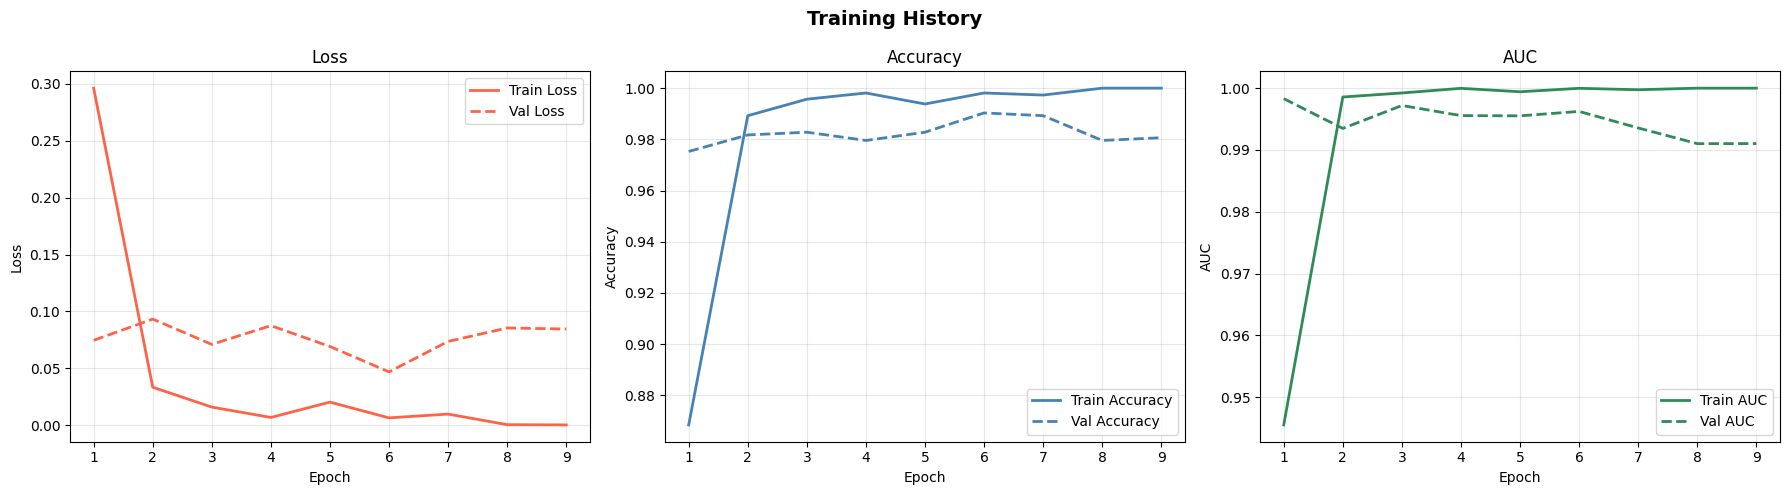

In [9]:
# --- Training Curves ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('loss',     'Loss',     'tomato'),
    ('accuracy', 'Accuracy', 'steelblue'),
    ('auc',      'AUC',      'seagreen'),
]

for ax, (metric, label, color) in zip(axes, metrics_to_plot):
    epochs_ran = range(1, len(history.history[metric]) + 1)
    ax.plot(epochs_ran, history.history[metric],
            label=f'Train {label}', color=color, linewidth=2)
    ax.plot(epochs_ran, history.history[f'val_{metric}'],
            label=f'Val {label}', color=color, linewidth=2, linestyle='--')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Evaluation

In [10]:
# --- Test-set predictions ---
y_prob  = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred  = (y_prob >= 0.5).astype(int)

# --- Keras evaluate (matches training metrics) ---
print("=" * 55)
print("Keras evaluate on test set:")
print("=" * 55)
test_results = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
for name, val in zip(model.metrics_names, test_results):
    print(f"  {name:12s}: {val:.4f}")

# --- sklearn classification report ---
print("\n" + "=" * 55)
print("Classification Report (threshold = 0.5):")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

# --- ROC-AUC ---
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

Keras evaluate on test set:
  loss        : 0.1118
  compile_metrics: 0.9776

Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

     Ham (0)       0.99      0.98      0.98       818
    Spam (1)       0.96      0.97      0.96       344

    accuracy                           0.98      1162
   macro avg       0.97      0.97      0.97      1162
weighted avg       0.98      0.98      0.98      1162

ROC-AUC Score: 0.9954


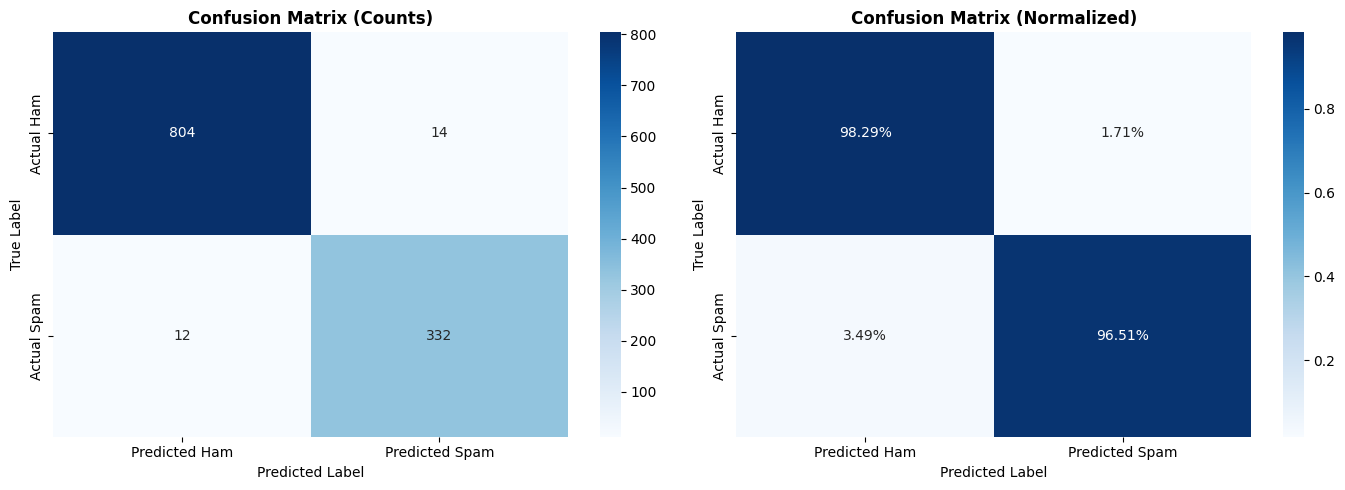

True  Negatives (ham correctly classified)  : 804
False Positives (ham misclassified as spam) : 14
False Negatives (spam misclassified as ham) : 12
True  Positives (spam correctly classified) : 332


In [11]:
# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Ham', 'Predicted Spam'],
    yticklabels=['Actual Ham', 'Actual Spam'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized confusion matrix (percentages)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=['Predicted Ham', 'Predicted Spam'],
    yticklabels=['Actual Ham', 'Actual Spam'],
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (ham correctly classified)  : {tn}")
print(f"False Positives (ham misclassified as spam) : {fp}")
print(f"False Negatives (spam misclassified as ham) : {fn}")
print(f"True  Positives (spam correctly classified) : {tp}")

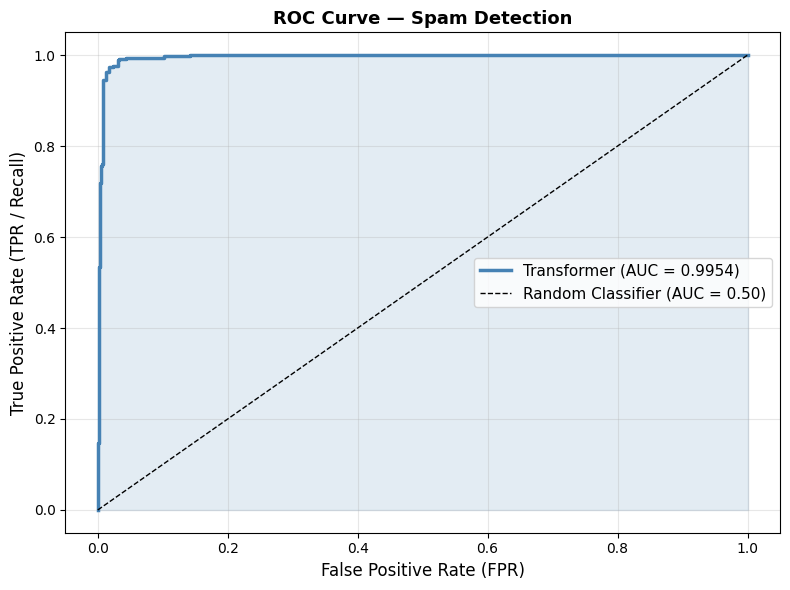

Optimal decision threshold (Youden's J): 0.0057
  → TPR at optimal: 0.9913
  → FPR at optimal: 0.0330


In [12]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Transformer (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.15, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('ROC Curve — Spam Detection', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

# Optimal threshold (maximizes TPR - FPR = Youden's J)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal decision threshold (Youden's J): {optimal_threshold:.4f}")
print(f"  → TPR at optimal: {tpr[optimal_idx]:.4f}")
print(f"  → FPR at optimal: {fpr[optimal_idx]:.4f}")

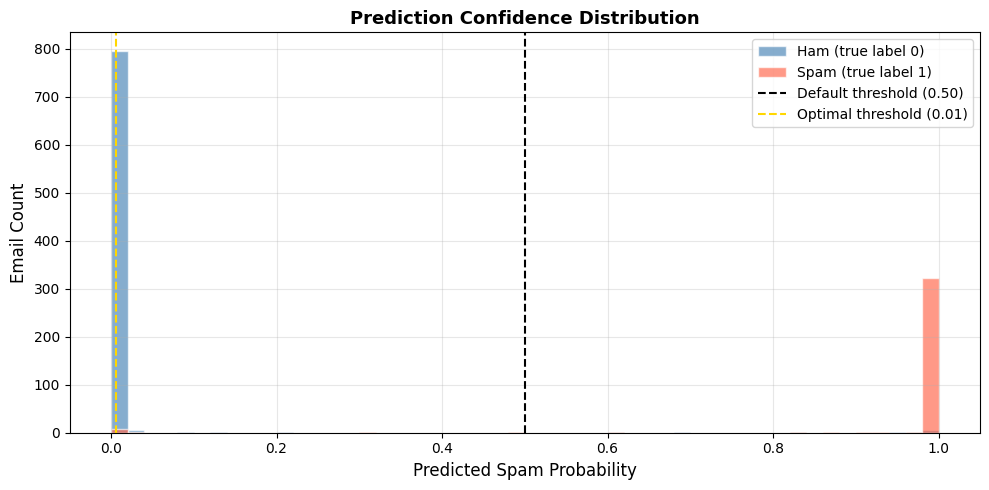

In [13]:
# --- Prediction Confidence Distribution ---
plt.figure(figsize=(10, 5))
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.65,
         color='steelblue', label='Ham (true label 0)', edgecolor='white')
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.65,
         color='tomato',    label='Spam (true label 1)', edgecolor='white')
plt.axvline(0.5, color='black',  linestyle='--', label='Default threshold (0.50)')
plt.axvline(optimal_threshold, color='gold', linestyle='--',
            label=f'Optimal threshold ({optimal_threshold:.2f})')
plt.xlabel('Predicted Spam Probability', fontsize=12)
plt.ylabel('Email Count', fontsize=12)
plt.title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# --- Summary Table ---
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Re-evaluate at optimal threshold too
y_pred_opt = (y_prob >= optimal_threshold).astype(int)

summary = pd.DataFrame({
    'Threshold': [0.5, optimal_threshold],
    'Accuracy' : [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_opt)],
    'Precision': [precision_score(y_test, y_pred), precision_score(y_test, y_pred_opt)],
    'Recall'   : [recall_score(y_test, y_pred), recall_score(y_test, y_pred_opt)],
    'F1-Score' : [f1_score(y_test, y_pred), f1_score(y_test, y_pred_opt)],
    'ROC-AUC'  : [roc_auc, roc_auc],
})
summary = summary.round(4)
summary.index = ['Default (0.50)', f'Optimal ({optimal_threshold:.2f})']
print("\nPerformance Summary:")
print(summary.to_string())


Performance Summary:
                Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Default (0.50)     0.5000    0.9776     0.9595  0.9651    0.9623   0.9954
Optimal (0.01)     0.0057    0.9742     0.9266  0.9913    0.9579   0.9954


## 9. Predict on New Emails

A reusable function that takes raw email text and returns a spam/ham verdict with confidence score.

In [15]:
def predict_email(email_texts, threshold=0.5):
    """
    Classify one or more raw emails as spam or ham.

    Parameters
    ----------
    email_texts : str or list of str
        Raw email text(s) (subject + body combined, or body alone).
    threshold : float
        Decision boundary for spam (default 0.5).
        Use optimal_threshold for best sensitivity/specificity balance.

    Returns
    -------
    pd.DataFrame with columns: email_preview, spam_probability, prediction
    """
    if isinstance(email_texts, str):
        email_texts = [email_texts]

    # Apply the same cleaning used during training
    cleaned = [clean_text(t) for t in email_texts]

    # Vectorize using the fitted vocabulary
    vectorized = text_vectorizer(np.array(cleaned)).numpy()

    # Model inference
    probs = model.predict(vectorized, verbose=0).flatten()

    results = pd.DataFrame({
        'email_preview'    : [t[:80] + '...' if len(t) > 80 else t for t in email_texts],
        'spam_probability' : probs.round(4),
        'prediction'       : ['SPAM' if p >= threshold else 'HAM' for p in probs],
        'confidence'       : [f"{max(p, 1-p)*100:.1f}%" for p in probs],
    })
    return results


# --- Demo predictions ---
test_emails = [
    # Clear spam
    "CONGRATULATIONS! You've been selected as our WINNER! Click here now to claim "
    "your FREE prize of $1,000,000!!! Limited time offer — ACT NOW!!!",

    # Clear ham
    "Hi John, just following up on our meeting from yesterday. Could you send me "
    "the agenda for next Tuesday's project review? Thanks.",

    # Phishing attempt
    "Dear valued customer, your account has been suspended. Verify your identity "
    "immediately by clicking the link below or your account will be permanently deleted.",

    # Legitimate newsletter
    "This week in security: patch Tuesday roundup, CVE analysis, and our monthly "
    "threat intelligence summary from the research team.",

    # Ambiguous marketing
    "Exclusive offer for our members — 50% off all premium subscriptions this weekend only.",
]

results = predict_email(test_emails, threshold=0.5)
print("Predictions on new emails (threshold = 0.50):")
print(results.to_string(index=False))

Predictions on new emails (threshold = 0.50):
                                                                      email_preview  spam_probability prediction confidence
CONGRATULATIONS! You've been selected as our WINNER! Click here now to claim you...            1.0000       SPAM     100.0%
Hi John, just following up on our meeting from yesterday. Could you send me the ...            0.0001        HAM     100.0%
Dear valued customer, your account has been suspended. Verify your identity imme...            0.9999       SPAM     100.0%
This week in security: patch Tuesday roundup, CVE analysis, and our monthly thre...            0.6423       SPAM      64.2%
Exclusive offer for our members — 50% off all premium subscriptions this weekend...            0.0648        HAM      93.5%


In [16]:
# Re-run with the optimal threshold for better spam recall
results_opt = predict_email(test_emails, threshold=optimal_threshold)
print(f"Predictions with optimal threshold ({optimal_threshold:.2f}):")
print(results_opt.to_string(index=False))

Predictions with optimal threshold (0.01):
                                                                      email_preview  spam_probability prediction confidence
CONGRATULATIONS! You've been selected as our WINNER! Click here now to claim you...            1.0000       SPAM     100.0%
Hi John, just following up on our meeting from yesterday. Could you send me the ...            0.0001        HAM     100.0%
Dear valued customer, your account has been suspended. Verify your identity imme...            0.9999       SPAM     100.0%
This week in security: patch Tuesday roundup, CVE analysis, and our monthly thre...            0.6423       SPAM      64.2%
Exclusive offer for our members — 50% off all premium subscriptions this weekend...            0.0648       SPAM      93.5%


In [17]:
# Interactive single-email prediction
def check_email(subject='', body='', threshold=0.5):
    """
    Quick check for a single email given subject and body separately.
    Mirrors the training preprocessing (subject + ' ' + body).
    """
    combined = (str(subject) + ' ' + str(body)).strip()
    result = predict_email(combined, threshold=threshold)
    row = result.iloc[0]
    print(f"Verdict      : {row['prediction']}")
    print(f"Spam prob.   : {row['spam_probability']:.4f}")
    print(f"Confidence   : {row['confidence']}")
    return row

# Example usage
print("--- Example: potential phishing email ---")
check_email(
    subject="Urgent: Verify your bank account",
    body="Your account shows suspicious activity. Login now to secure it.",
    threshold=0.5
)

--- Example: potential phishing email ---
Verdict      : SPAM
Spam prob.   : 0.9781
Confidence   : 97.8%


email_preview       Urgent: Verify your bank account Your account ...
spam_probability                                               0.9781
prediction                                                       SPAM
confidence                                                      97.8%
Name: 0, dtype: object

## Analysis Summary

| Component | Choice | Rationale |
|---|---|---|
| Vocabulary | 8,000 tokens | Covers spam/ham lexicon without padding memory |
| Sequence length | 200 tokens | Captures subject + key body content |
| Embedding dim | 64 | Expressive enough; small for CPU |
| Attention heads | 4 | 16 dims/head — captures syntax, semantics, formatting cues |
| Transformer blocks | 2 | Two layers for hierarchical feature learning |
| Class weights | Computed | Corrects spam/ham imbalance in SpamAssassin |
| Early stopping | patience=3 | Prevents overfitting; restores best weights |
| ReduceLROnPlateau | factor=0.5 | Refines learning when plateau is detected |

**Extension to anomaly detection**: The same transformer architecture can be repurposed by training on *only* ham emails as a reconstruction/autoencoder baseline, then flagging emails whose representations deviate significantly — a one-class classification approach for detecting novel attack patterns not seen during training.